In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from collections import Counter

# 1. Đọc dữ liệu từ file Excel và LOẠI BỎ TRÙNG LẶP
print("--- BƯỚC 1: ĐỌC VÀ LỌC DỮ LIỆU ---")
df = pd.read_excel('heart.xlsx') 
print(f"Kích thước ban đầu (có trùng lặp): {df.shape}")

# Xóa các dòng nhân bản, trả về bộ gốc
df = df.drop_duplicates()
print(f"Kích thước sau khi lọc trùng (bộ gốc Cleveland): {df.shape}")
print(f"Phân phối nhãn bệnh thực tế: {Counter(df['target'])}") 
print("-" * 30)

# Tách biến độc lập (X) và biến mục tiêu (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Chuẩn hóa dữ liệu (StandardScaler)
print("--- BƯỚC 2: CHUẨN HÓA VÀ ĐIỀN KHUYẾT (KNN) ---")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# 3. Điền khuyết bằng KNN Imputer
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X_scaled)

# Đóng gói lại thành DataFrame 
X_final = pd.DataFrame(X_imputed, columns=X.columns)

print("Đã hoàn tất chuẩn hóa và điền khuyết.")
print("DỮ LIỆU ĐÃ SẠCH! Chuẩn bị lắp ráp mô hình thôi.")

--- BƯỚC 1: ĐỌC VÀ LỌC DỮ LIỆU ---
Kích thước ban đầu (có trùng lặp): (1025, 14)
Kích thước sau khi lọc trùng (bộ gốc Cleveland): (302, 14)
Phân phối nhãn bệnh thực tế: Counter({1: 164, 0: 138})
------------------------------
--- BƯỚC 2: CHUẨN HÓA VÀ ĐIỀN KHUYẾT (KNN) ---
Đã hoàn tất chuẩn hóa và điền khuyết.
DỮ LIỆU ĐÃ SẠCH! Chuẩn bị lắp ráp mô hình thôi.


In [3]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# 4. Chia tập Train / Test (Tỉ lệ 80% học - 20% thi)
print("--- BƯỚC 4: CHIA TẬP TRAIN & TEST ---")
# Dùng stratify=y để đảm bảo tỉ lệ người bệnh/khỏe mạnh chia đều cho cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

print(f"Số lượng mẫu đem đi dạy học (Train): {X_train.shape[0]}")
print(f"Số lượng mẫu đem đi làm bài thi (Test): {X_test.shape[0]}")
print("-" * 30)

# 5. Khởi tạo và huấn luyện thử thuật toán XGBoost
print("--- BƯỚC 5: CHẠY THỬ MÔ HÌNH ---")
# Cài đặt cấu hình cơ bản cho XGBoost
model_xgb = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Cho AI bắt đầu học trên tập Train
model_xgb.fit(X_train, y_train)

# Làm bài kiểm tra trên tập Test
y_pred = model_xgb.predict(X_test)

# Chấm điểm
print("Độ chính xác (Accuracy) ban đầu:", accuracy_score(y_test, y_pred))
print("\nBáo cáo chi tiết (Classification Report):")
print(classification_report(y_test, y_pred))

--- BƯỚC 4: CHIA TẬP TRAIN & TEST ---
Số lượng mẫu đem đi dạy học (Train): 241
Số lượng mẫu đem đi làm bài thi (Test): 61
------------------------------
--- BƯỚC 5: CHẠY THỬ MÔ HÌNH ---
Độ chính xác (Accuracy) ban đầu: 0.7213114754098361

Báo cáo chi tiết (Classification Report):
              precision    recall  f1-score   support

           0       0.70      0.68      0.69        28
           1       0.74      0.76      0.75        33

    accuracy                           0.72        61
   macro avg       0.72      0.72      0.72        61
weighted avg       0.72      0.72      0.72        61



c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:32:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- BƯỚC 6: GIẢI THÍCH MÔ HÌNH BẰNG SHAP ---


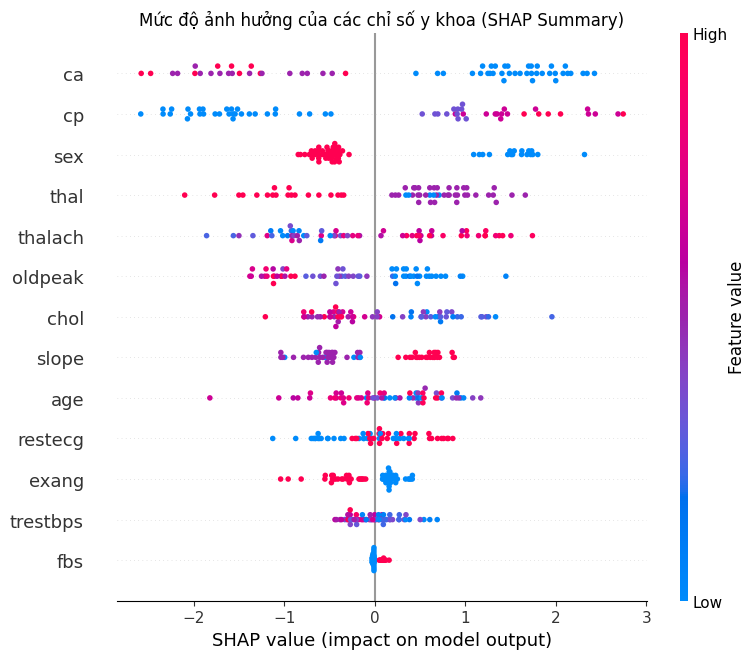

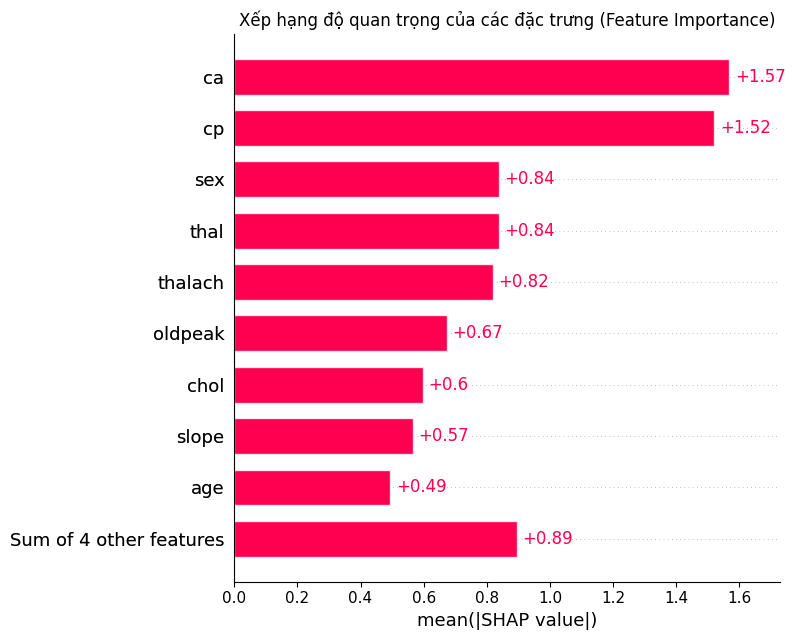

In [4]:
import shap
import matplotlib.pyplot as plt

print("--- BƯỚC 6: GIẢI THÍCH MÔ HÌNH BẰNG SHAP ---")
# Khởi tạo SHAP Explainer cho mô hình XGBoost
explainer = shap.Explainer(model_xgb, X_train)
shap_values = explainer(X_test)

# 1. Vẽ biểu đồ Summary Plot (Xem tổng quan các đặc trưng quan trọng nhất)
plt.figure(figsize=(10, 6))
plt.title("Mức độ ảnh hưởng của các chỉ số y khoa (SHAP Summary)")
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# 2. Vẽ biểu đồ Bar Plot (Tính trung bình độ quan trọng)
plt.figure(figsize=(10, 6))
plt.title("Xếp hạng độ quan trọng của các đặc trưng (Feature Importance)")
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score

print("--- CUỘC ĐUA: LOGISTIC REGRESSION vs XGBOOST (TUNED) ---")

# 1. Chạy Logistic Regression (Nhà vô địch từ Bài 21)
# Tăng max_iter lên 1000 để đảm bảo hội tụ tốt với dữ liệu đã scale
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# 2. Dùng GridSearchCV để "ép xung" XGBoost
param_grid = {
    'max_depth': [3, 5, 7],           
    'learning_rate': [0.01, 0.05, 0.1], 
    'n_estimators': [50, 100, 200]   
}

xgb_base = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_search = GridSearchCV(estimator=xgb_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Lấy mô hình XGBoost xịn nhất và dự đoán
best_xgb = grid_search.best_estimator_
xgb_tuned_pred = best_xgb.predict(X_test)
xgb_tuned_acc = accuracy_score(y_test, xgb_tuned_pred)

# 3. Bảng xếp hạng chung cuộc
print(f"1. Độ chính xác Logistic Regression : {lr_acc:.4f}")
print(f"2. Độ chính xác XGBoost (Đã ép xung) : {xgb_tuned_acc:.4f}")
print("-" * 30)
print("Cấu hình XGBoost tốt nhất tìm được:", grid_search.best_params_)

--- CUỘC ĐUA: LOGISTIC REGRESSION vs XGBOOST (TUNED) ---
1. Độ chính xác Logistic Regression : 0.8033
2. Độ chính xác XGBoost (Đã ép xung) : 0.7377
------------------------------
Cấu hình XGBoost tốt nhất tìm được: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:42:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- BƯỚC CUỐI: GIẢI THÍCH LOGISTIC REGRESSION BẰNG SHAP ---


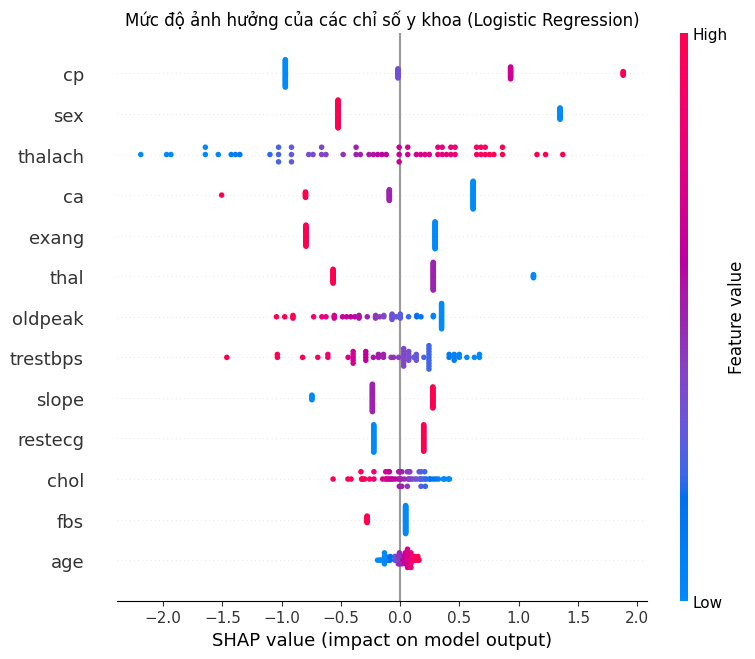

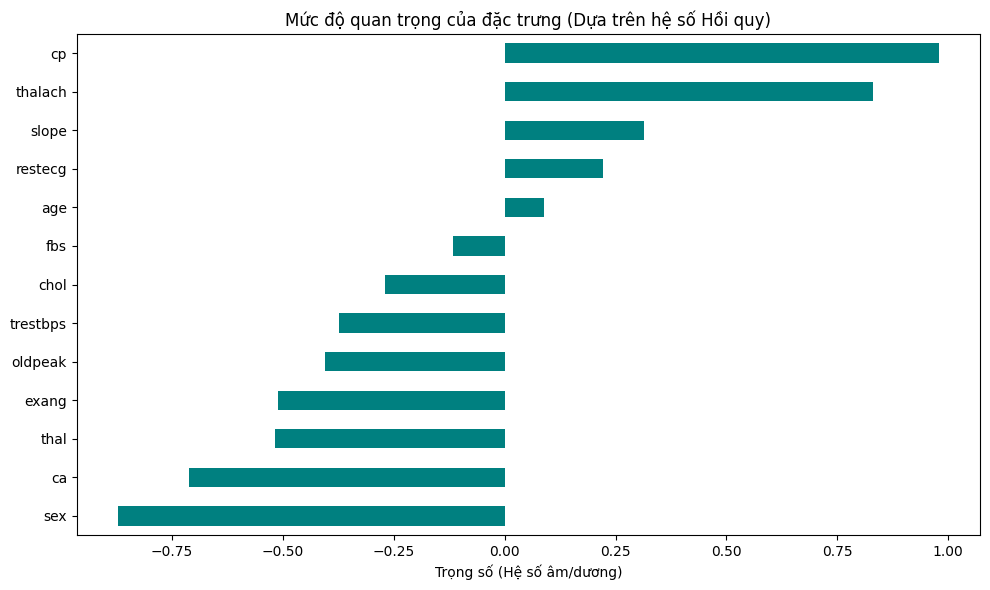

In [6]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

print("--- BƯỚC CUỐI: GIẢI THÍCH LOGISTIC REGRESSION BẰNG SHAP ---")
# SHAP dùng LinearExplainer chuyên dụng cho các mô hình Hồi quy tuyến tính
explainer_lr = shap.LinearExplainer(lr_model, X_train)
shap_values_lr = explainer_lr(X_test)

# 1. Vẽ biểu đồ Summary Plot của SHAP
plt.figure(figsize=(10, 6))
plt.title("Mức độ ảnh hưởng của các chỉ số y khoa (Logistic Regression)")
shap.summary_plot(shap_values_lr, X_test, show=False)
plt.tight_layout()
plt.show()

# 2. Vẽ biểu đồ Trọng số (Feature Importance) tự nhiên của Logistic Regression
plt.figure(figsize=(10, 6))
plt.title("Mức độ quan trọng của đặc trưng (Dựa trên hệ số Hồi quy)")
importances = lr_model.coef_[0]
importances_series = pd.Series(importances, index=X_train.columns).sort_values()
importances_series.plot(kind='barh', color='teal')
plt.xlabel("Trọng số (Hệ số âm/dương)")
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

print("--- KỸ THUẬT BOOTSTRAPPING (LẶP 1000 LẦN) ---")
n_iterations = 1000
scores = []

# Cho mô hình Logistic Regression dự đoán 1000 lần trên các tập Test ngẫu nhiên
for i in range(n_iterations):
    # Bốc thăm ngẫu nhiên (có hoàn lại) từ tập X_test ban đầu
    X_bs, y_bs = resample(X_test, y_test, random_state=i)
    
    # Chấm điểm cho từng lần lặp
    y_pred_bs = lr_model.predict(X_bs)
    score = accuracy_score(y_bs, y_pred_bs)
    scores.append(score)

# Tính toán kết quả thống kê
mean_score = np.mean(scores)
lower_bound = np.percentile(scores, 2.5)  # Cận dưới của khoảng tin cậy 95%
upper_bound = np.percentile(scores, 97.5) # Cận trên của khoảng tin cậy 95%

print(f"1. Độ chính xác trung bình (sau 1000 lần): {mean_score:.4f}")
print(f"2. Khoảng tin cậy 95%: Từ {lower_bound:.4f} đến {upper_bound:.4f}")

--- KỸ THUẬT BOOTSTRAPPING (LẶP 1000 LẦN) ---
1. Độ chính xác trung bình (sau 1000 lần): 0.8011
2. Khoảng tin cậy 95%: Từ 0.7049 đến 0.9016
